# Miniproyecto 3: Clasificación de animales

## Entrega 1

La clasificación es una de las principales tareas en machine learning. En particular, la clasificación de imágenes consiste en asignar una etiqueta a una imagen a partir de un conjunto finito de clases posibles. En el enfoque clásico de machine learning, este proceso se basa en la extracción de descriptores o características, que son vectores que representan información relevante de una imagen y permiten categorizarla, y posteriormente en su clasificación mediante modelos clasificadores.

Aunque el problema parece sencillo, en la práctica presenta varios desafíos. Las clases pueden tener una gran variabilidad tanto entre sí como dentro de cada una, lo que dificulta la clasificación automática. En visión por computador, la precisión de los modelos depende tanto de la calidad de los descriptores extraídos como del rendimiento de los clasificadores utilizados para separar las categorías.

En este Mini-proyecto, exploraremos diferentes tipos de descriptores visuales, centrándonos en tres principales:

1. Descriptores basados en Color (como histogramas de color, que capturan la distribución de colores en la imagen).

2. Descriptores de Textura (como patrones de intensidad que reflejan la rugosidad o suavidad de una superficie).

3. Descriptores de Forma (que representan contornos y estructuras geométricas de los objetos en la imagen).

Estos descriptores transforman la información visual en representaciones numéricas que los algoritmos pueden procesar para la clasificación. Una vez obtenidos, utilizaremos modelos clasificadores para aprender fronteras de decisión y clasificar nuevas imágenes.

### Base de Datos y Asignación de Clases
Trabajaremos con la base de datos [iNaturalist](https://github.com/visipedia/inat_comp.git), un conjunto de imágenes de seres vivos utilizado en tareas de clasificación. Para este proyecto, nos enfocaremos en un subconjunto de 23 especies de mamíferos con el mayor número de imágenes dentro de las versiones del dataset (2017, 2018 y 2021). Las clases estarán identificadas por sus nombres científicos.

Dado que el dataset sigue siendo grande, y para garantizar una experiencia equitativa y desafiante para cada grupo, cada equipo trabajará con cinco especies de mamíferos. Para mantener un número equilibrado de imágenes por grupo, hemos dividido las 23 especies en cinco grupos, cada uno con diferentes cantidades de imágenes. De manera aleatoria todos los equipos obtendrán una especie de cada grupo, asegurando así que todos trabajen con un conjunto similar en tamaño.

### Consideraciones Adicionales
Es importante notar que las imágenes del dataset no solo incluyen avistamientos directos de los animales, sino también huellas, excrementos y otros rastros. Esto puede hacer que algunas imágenes sean difíciles de clasificar, incluso para algoritmos avanzados.


### Parte 1: Exploración de la base de datos

#### Parte 1.1: Entrega de las clases
En las siguientes celdas, encontrarán las clases asignadas a su grupo. Para verlas, deben asignar a la variable `grupo` el número correspondiente a su equipo dentro del Bloque Neón.

In [29]:
# importar librerías importantes
import os
import random
import numpy as np
from glob import glob
from matplotlib import pyplot as plt
from collections import Counter
import pandas as pd
import cv2

In [11]:
group = 13 

In [12]:
def determine_classes(group: int) -> list:
    """Función que determina las clases a utilizar en el proyecto.

    Args:
        group (int): Número de grupo.

    Returns:
        list: Lista con los nombres de las clases a utilizar.
    """
    # Se fija la semilla para reproducibilidad
    random.seed(group)
    
    # Se obtienen las categorías y la cantidad de imágenes por categoría
    stats = [('Canis latrans', 1286), ('Castor canadensis', 854), ('Dasypus novemcinctus', 515), ('Didelphis virginiana', 713), 
             ('Lepus californicus', 515), ('Lynx rufus', 854), ('Megaptera novaeangliae', 515), ('Mephitis mephitis', 515), 
             ('Odocoileus hemionus', 1286), ('Odocoileus virginianus', 1795), ('Otospermophilus beecheyi', 854), 
             ('Otospermophilus variegatus', 515), ('Phoca vitulina', 713), ('Procyon lotor', 1286), ('Sciurus carolinensis', 1795), 
             ('Sciurus niger', 1795), ('Sylvilagus audubonii', 515), ('Sylvilagus floridanus', 854), ('Tamias striatus', 854), 
             ('Tamiasciurus hudsonicus', 713), ('Urocyon cinereoargenteus', 515), ('Ursus americanus', 713), ('Vulpes vulpes', 854)]
    
    # Se agrupan las categorías por cantidad de imágenes
    clusters = {}
    for category, num_images in stats:
        if num_images in clusters:
            clusters[num_images].append(category)
        else:
            clusters[num_images] = [category]
    
    # Se selecciona una categoría aleatoria de cada cluster
    categories = []
    for cluster_categories in clusters.values():
        categories += [random.choice(cluster_categories)]
    return categories

assert group is not None, "Por favor, asigna un número de grupo a la variable 'group'."
assert group > 0, "El número de grupo debe ser mayor que 0."
assert group <= 28, "El número de grupo debe ser menor o igual que 28."

categories = determine_classes(group)
print(f"Las classes que usarán en este Mini-proyecto serán:\n{", ".join(categories)}.")

Las classes que usarán en este Mini-proyecto serán:
Odocoileus hemionus, Otospermophilus beecheyi, Sylvilagus audubonii, Phoca vitulina, Sciurus niger.


Al igual que en los mini-proyectos anteriores, es fundamental comenzar analizando la base de datos con la que trabajaremos. Primero, vamos a crear un identificador único (ID) para cada una de las clases de mamíferos. Para ello, generaremos un diccionario en el que las claves sean los nombres de los mamíferos ordenados alfabéticamente, y los valores sean los IDs correspondientes. Recuerden que el ID debe asignarse en el mismo orden alfabético, es decir, el primer animal en la lista debe tener el ID 0.

A continuación, deberán implementar una función que genere dos listas:

1. Una lista con las rutas de las imágenes correspondientes al split.

2. Una lista con las etiquetas, que son los IDs de los animales asignados, utilizando el diccionario que mapea de nombre a ID.

**Nota:** Asegúrense de que las listas solo contengan las clases que se les han asignado a su grupo y no todas las categorías disponibles en el dataset.

In [ ]:
dict_labels = {} # Cambiar por un diccionario con las etiquetas de las clases 

# YOUR CODE HERE
clases= ["Odocoileus hemionus","Otospermophilus beecheyi","Phoca vitulina","Sciurus niger", "Sylvilagus audubonii"]
dict_labels={"Odocoileus hemionus":0, "Otospermophilus beecheyi":1,"Phoca vitulina":2,"Sciurus niger":3, "Sylvilagus audubonii":4}


def get_data(subset: str) -> tuple[list, list]:
    """Función que obtiene las rutas de las imágenes y sus etiquetas.

    Args:
        subset (str): Nombre del subconjunto de datos

    Returns:
        tuple[list, list]: Rutas de las imágenes y sus etiquetas.
    """
    
    
    paths=[] # Cambiar por una lista con las rutas de las imágenes 
    labels=[] # Cambiar por una lista con las etiquetas de las imágenes
    
    # Construimos la ruta base al subconjunto (train, valid o test)
    
    base_path=f"dataset/{subset}"
    
    # Recorremos cada una de las clases que nos asignaron
    for nombre in clases:
        # Construimos la ruta de la carpeta de esa clase
        class_path = os.path.join(base_path, nombre)
        # Usamos glob para obtener todas las imágenes dentro de esa carpeta
        image_paths = glob(os.path.join(class_path, "*"))
        # Ahora recorremos cada imagen encontrada
        for img_path in image_paths:
            # Guardamos la ruta de la imagen
            paths.append(img_path)
            # Guardamos la etiqueta correspondiente usando el diccionario
            # Convertimos el nombre de la clase a su ID numérico
            labels.append(dict_labels[nombre])
    # Al final devolvemos ambas listas
    return paths, labels
train_paths, train_labels = get_data("train")
valid_paths, valid_labels = get_data("valid")
test_paths, test_labels = get_data("test")

In [18]:
assert len(train_paths) > 0, "No se ha cargado ningún dato de entrenamiento"
assert len(train_paths) == 5163, "El número de datos de entrenamiento no es correcto"
assert len(valid_paths) > 0, "No se ha cargado ningún dato de validación"
assert len(valid_paths) == 1723, "El número de datos de validación no es correcto"
assert len(test_paths) > 0, "No se ha cargado ningún dato de test"
assert len(test_paths) == 1724, "El número de datos de test no es correcto"

assert type(train_paths[0]) == str, "Los datos de entrenamiento no tienen la forma correcta"
assert type(valid_paths[0]) == str, "Los datos de validación no tienen la forma correcta"
assert type(test_paths[0]) == str, "Los datos de test no tienen la forma correcta"

assert type(train_labels[0]) == int, "Las etiquetas de entrenamiento no tienen la forma correcta"
assert type(valid_labels[0]) == int, "Las etiquetas de validación no tienen la forma correcta"
assert type(test_labels[0]) == int, "Las etiquetas de test no tienen la forma correcta"

assert len(dict_labels) == len(categories), "El diccionario de labels no tiene la longitud correcta"

categories_sorted = sorted(categories)
assert list(dict_labels.keys()) == categories_sorted, "Las llaves del diccionario de labels no son correctas"
assert list(dict_labels.values()) == list(range(len(categories))), "Los valores del diccionario de labels no son correctos"

assert min([dict_labels[train_paths[i].split(os.sep)[-2]] == train_labels[i] for i in range(len(train_paths))]), "Las etiquetas de entrenamiento no coinciden"
assert min([dict_labels[valid_paths[i].split(os.sep)[-2]] == valid_labels[i] for i in range(len(valid_paths))]), "Las etiquetas de validación no coinciden"
assert min([dict_labels[test_paths[i].split(os.sep)[-2]] == test_labels[i] for i in range(len(test_paths))]), "Las etiquetas de test no coinciden"

En el informe del miniproyecto, en la sección dedicada al análisis del Dataset, debes incluir las siguientes estadísticas y análisis:

1. Cantidad de imágenes por clase:

    Debes reportar cuántas imágenes hay de cada clase en cada uno de los conjuntos (train, valid y test). Presenta estos datos en una tabla o gráfico para facilitar la interpretación.

2. Distribución de datos en los folds:

    Analiza y comenta sobre la distribución de los datos en los diferentes conjuntos (train, valid y test). ¿Están equilibradas las clases o alguna tiene más ejemplos que las demás?

3. Ejemplos visuales:

    Incluye algunas imágenes de ejemplo para cada clase, extraídas de los distintos conjuntos (train, valid y test). Muestra al menos una imagen de cada clase para que quede claro cómo lucen visualmente las diferentes categorías.

4. Otras estadísticas relevantes:

    Además, pueden presentar cualquiera otra estadística que crean relevante. Ejemplo: ¿Todas las imágenes están a color, es decir, hay algunas imágenes en escala de grises?

# 1 cantidad de imágenes por clase

# 1.1 Función para contar cuántas imágenes hay por clase


In [ ]:
def count_by_class(labels: list, dict_labels: dict) -> dict:
    """
    Cuenta cuántas imágenes hay por cada clase a partir de la lista de labels.

    Args:
        labels (list): Lista de etiquetas numéricas.
        dict_labels (dict): Diccionario clase -> ID.

    Returns:
        dict: Diccionario clase -> cantidad de imágenes.
    """

    # Invertimos el diccionario para pasar de ID -> nombre de clase
    id_to_class = {idx: class_name for class_name, idx in dict_labels.items()}
    
    # Contamos cuántas veces aparece cada label
    counts = Counter(labels)
    
    # Construimos un nuevo diccionario con nombres de clase como llaves
    class_counts = {id_to_class[idx]: counts.get(idx, 0) for idx in sorted(id_to_class)}
    
    return class_counts

## 1.2. Función para hacer la gráfica

In [23]:
def plot_horizontal_bars(class_counts: dict, title: str, color: str = "skyblue"):
    """
    Grafica una barra horizontal con el número de imágenes por clase.

    Args:
        class_counts (dict): Diccionario clase -> cantidad.
        title (str): Título de la gráfica.
        color (str): Color de las barras.
    """
    # Guardamos por separado los nombres de clases y sus cantidades
    class_names = list(class_counts.keys())
    values = list(class_counts.values())
    
    # Creamos la figura
    plt.figure(figsize=(10, 5))
    
    # Hacemos la gráfica horizontal
    bars = plt.barh(class_names, values, color=color)
    
    # Ponemos título y nombres de ejes
    plt.title(title, fontsize=14)
    plt.xlabel("Número de imágenes")
    plt.ylabel("Clase")
    
    # Escribimos el valor al final de cada barra
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 1,                         
            bar.get_y() + bar.get_height()/2, 
            str(int(width)),                  
            va='center'
        )

    plt.tight_layout()
    plt.show()

## 1.3. Contar imágenes en train, valid y test

In [ ]:
train_counts = count_by_class(train_labels, dict_labels)
valid_counts = count_by_class(valid_labels, dict_labels)
test_counts  = count_by_class(test_labels, dict_labels)

## 1.4. Graficar cada subconjunto

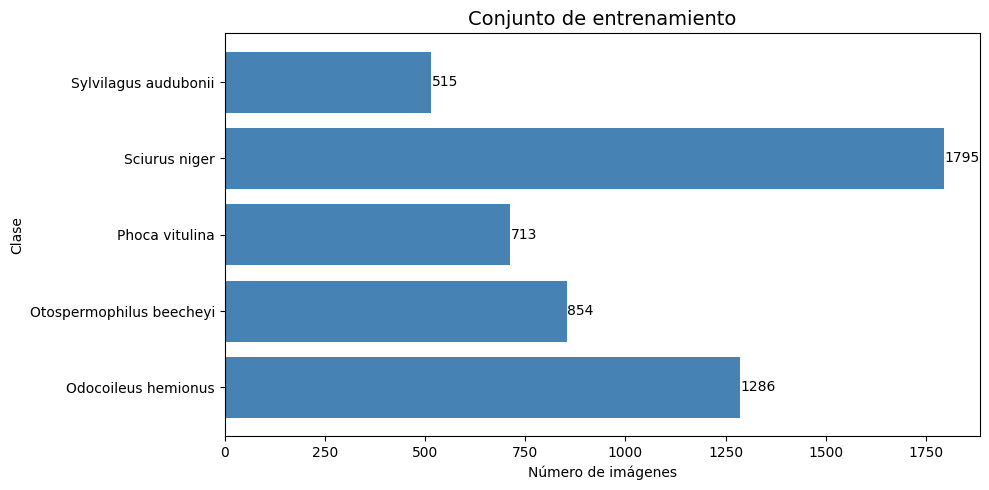

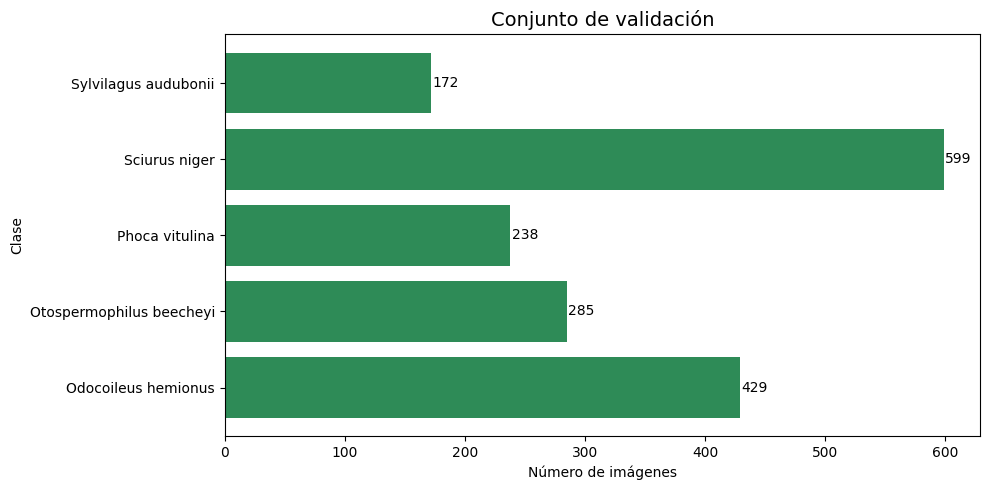

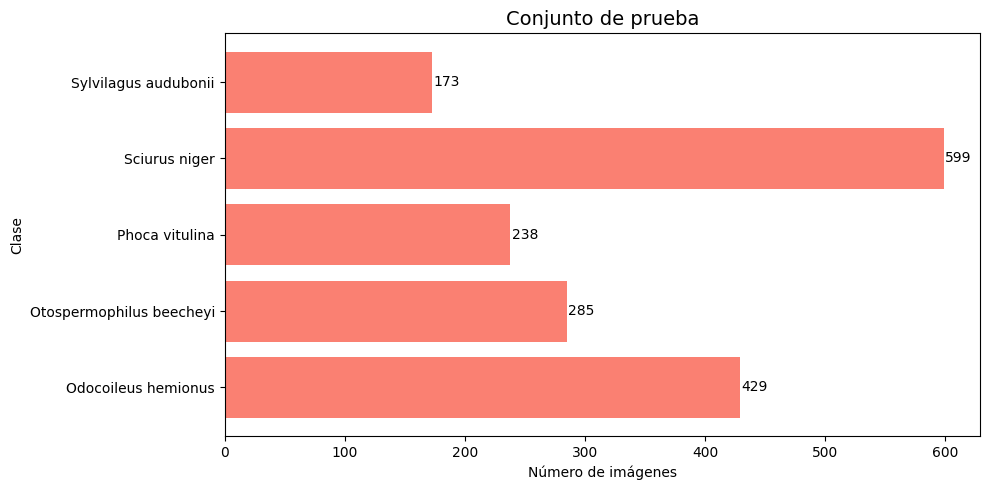

In [33]:
plot_horizontal_bars(train_counts, "Conjunto de entrenamiento", color="steelblue")
plot_horizontal_bars(valid_counts, "Conjunto de validación", color="seagreen")
plot_horizontal_bars(test_counts, "Conjunto de prueba", color="salmon")

# 2 Tabla con proporciones por clase y conjunto de datos

In [54]:
def normalize_counts(class_counts: dict) -> dict:
    """
    Convierte un diccionario de conteos a proporciones.

    Args:
        class_counts (dict): clase a número de imágenes

    Returns:
        dict: clase a proporción
    """
    total=sum(class_counts.values())#calculé el total de imágenes en el subconjunto
    #dividimos cada valor por el total
    normalized={cls:count/total for cls,count in class_counts.items()}#convertimos los conteos en proporciones
    return normalized#retorné el diccionario con proporciones

# normalizar cada conjunto
train_norm=normalize_counts(train_counts)#apliqué la normalización al conjunto de entrenamiento
valid_norm=normalize_counts(valid_counts)#apliqué la normalización al conjunto de validación
test_norm=normalize_counts(test_counts)#apliqué la normalización al conjunto de prueba

# construir la tabla final
# crear lista de clases
class_names=list(train_norm.keys())#obtuvimos los nombres de las clases a partir del diccionario

# Construir DataFrame
df_proportions=pd.DataFrame({"Clase":class_names,"Train":[train_norm[cls] for cls in class_names],"Valid":[valid_norm[cls] for cls in class_names],"Test":[test_norm[cls] for cls in class_names]})#construimos la tabla con las proporciones por clase y subconjunto

df_proportions#mostrar la tabla final con las proporciones

,Clase,Train,Valid,Test
0,Odocoileus hemionus,0.249080,0.248984,0.248840
1,Otospermophilus beecheyi,0.165408,0.165409,0.165313
2,Phoca vitulina,0.138098,0.138131,0.138051
3,Sciurus niger,0.347666,0.347649,0.347448
4,Sylvilagus audubonii,0.099748,0.099826,0.100348


### Se observa que la distribución de las clases es bastante consistente entre los conjuntos de train, valid y test, ya que los valores para cada especie son aproximadente iguales por decimales en los tres subconjuntos. Sin embargo, también se evidencia que el dataset está desbalanceado entre clases. Por ejemplo, la clase Sciurus niger presenta la mayor proporción de 34.7%, mientras que Sylvilagus audubonii tiene una menor cerca de 10%.

# 3 Visualización de los conjuntos y clases

## 3.1 función para extraer un ejemplo de cada conjunto de cada clase

In [57]:
def example(paths,labels,dict_labels):
    """
    Obtiene una imagen de ejemplo por cada clase.
    
    Returns:
        dict: clase -> path de una imagen
    """
    # Invertimos el diccionario para poder pasar de ID a nombre de clase
    id_to_class={idx:cls for cls,idx in dict_labels.items()}#esto permite traducir la etiqueta numérica al nombre de la especie
    
    # Creamos un diccionario donde vamos a guardar una imagen por clase
    examples={}
    
    # Recorremos simultáneamente las rutas de las imágenes y sus etiquetas
    for path,label in zip(paths,labels):
        class_name=id_to_class[label]#obtenemos el nombre de la clase correspondiente a la imagen
        
        # Si aún no hemos guardado una imagen de esta clase, la almacenamos
        if class_name not in examples:
            examples[class_name]=path#guardamos la primera imagen que encontramos para esa clase
        
        # Si ya tenemos una imagen por cada clase, detenemos el ciclo para no seguir recorriendo innecesariamente
        if len(examples)==len(dict_labels):
            break
    
    # Retornamos el diccionario con una imagen de ejemplo por cada clase
    return examples

## 3.2 Obtener ejemplos para cada subset

In [56]:
train_examples=example(train_paths, train_labels, dict_labels)
valid_examples=example(valid_paths, valid_labels, dict_labels)
test_examples=example(test_paths, test_labels, dict_labels)


## 3.3. Función para crear tabla

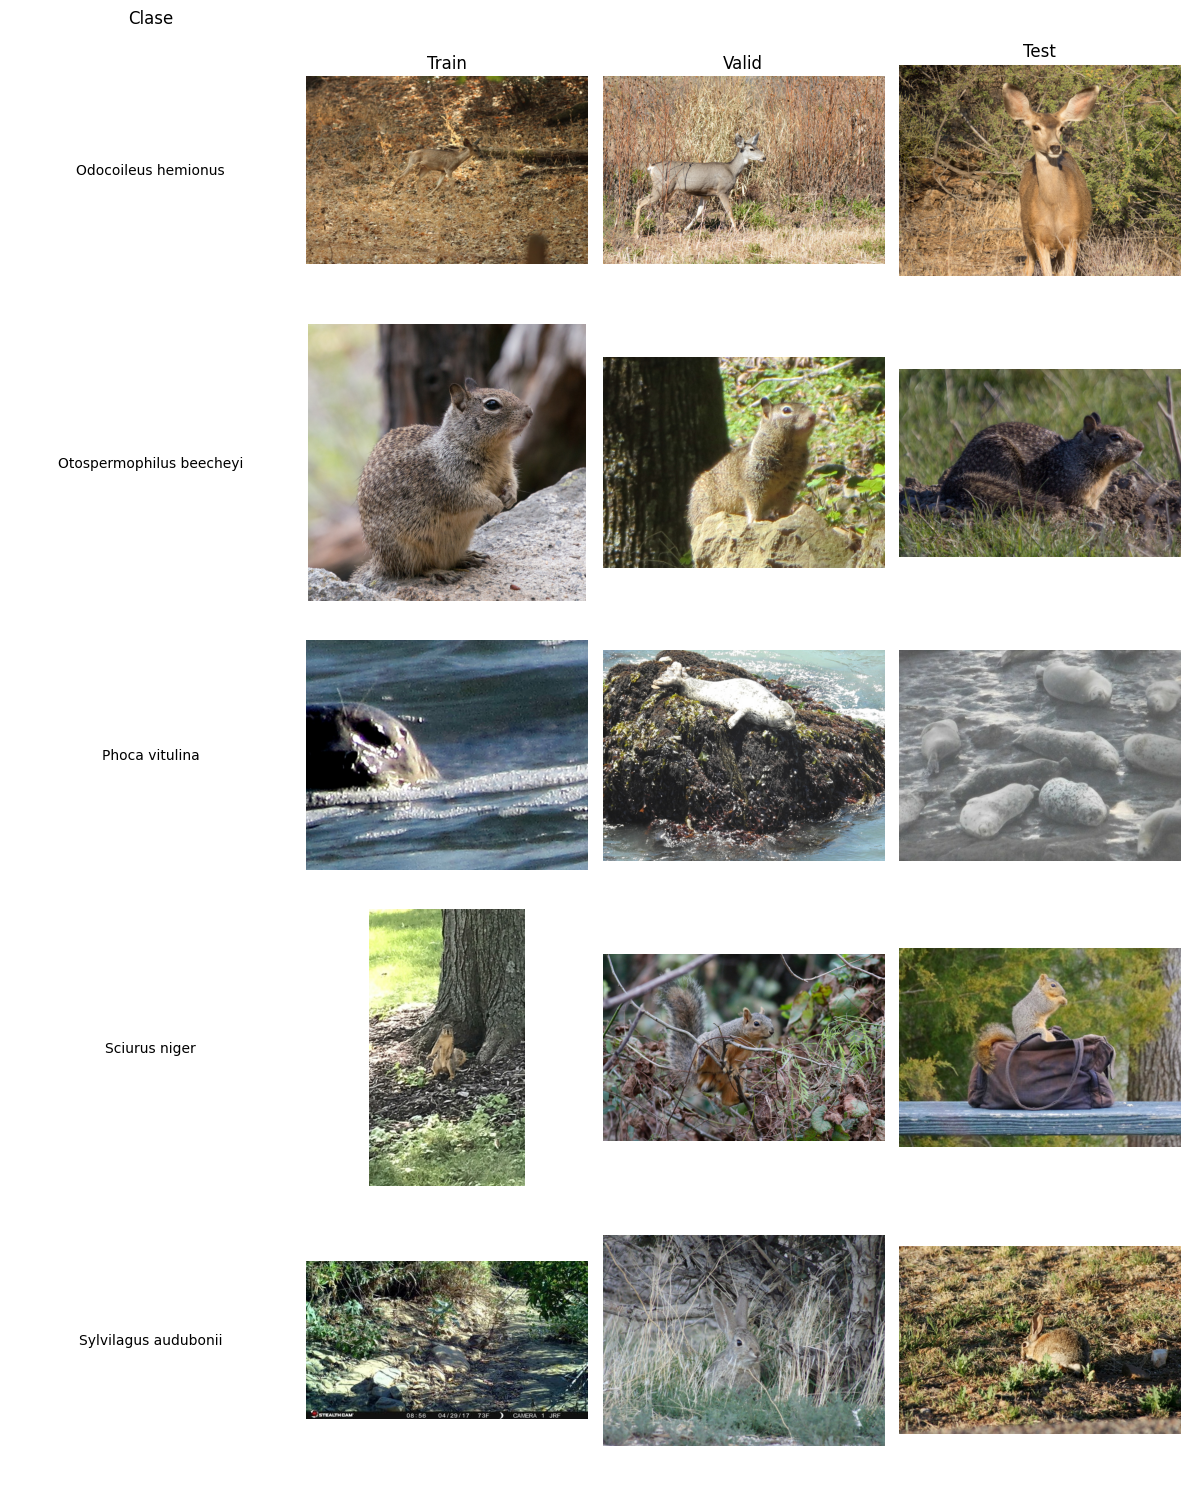

In [ ]:
def plot_examples_table(train_ex, valid_ex, test_ex):
    classes = list(train_ex.keys())
    fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3 * len(classes)))
    # Encabezados
    headers = ["Clase", "Train", "Valid", "Test"]
    for col in range(4):
        axes[0, col].set_title(headers[col], fontsize=12)
    for i, cls in enumerate(classes):
        # Columna 0: nombre de la clase (texto)
        axes[i, 0].text(0.5, 0.5, cls, ha='center', va='center')
        axes[i, 0].axis('off')
        # Train
        img = cv2.imread(train_ex[cls])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, 1].imshow(img)
        axes[i, 1].axis('off')
        # Valid
        img = cv2.imread(valid_ex[cls])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, 2].imshow(img)
        axes[i, 2].axis('off')
        # Test
        img = cv2.imread(test_ex[cls])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, 3].imshow(img)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

# tabla
plot_examples_table(train_examples, valid_examples, test_examples)

# 4 Demás estadísticas (cantidad de imágenes en escala de grises, proporción de color y tamaño promedio)

### 4.1. Función para analizar imágenes

In [58]:
def analyze_images(paths:list):
    """
    Analiza si las imágenes son RGB o escala de grises
    y obtiene estadísticas de tamaño.
    
    Args:
        paths (list): lista de rutas de imágenes
        
    Returns:
        dict: estadísticas calculadas
    """
    gray_count=0#contador de imágenes en escala de grises
    color_count=0#contador de imágenes a color
    heights=[]#lista para almacenar alturas
    widths=[]#lista para almacenar anchos
    
    for path in paths:#recorremos todas las rutas de imágenes
        img=cv2.imread(path)#leemos la imagen con OpenCV
        
        if img is None:#si la imagen no se pudo cargar, la ignoramos
            continue
        
        #obtener dimensiones
        h,w=img.shape[:2]#extraemos alto y ancho de la imagen
        heights.append(h)#guardamos la altura
        widths.append(w)#guardamos el ancho
        
        #revisar si es escala de grises
        #(si los 3 canales son iguales)
        if len(img.shape)==2:#si la imagen tiene solo una dimensión de canal, es gris
            gray_count+=1
        else:
            #verificamos si los tres canales son iguales (aunque tenga 3 canales)
            if (img[:,:,0]==img[:,:,1]).all() and (img[:,:,1]==img[:,:,2]).all():
                gray_count+=1#es técnicamente gris aunque esté en formato de 3 canales
            else:
                color_count+=1#la imagen sí contiene información de color real
    
    total=gray_count+color_count#calculamos el total de imágenes analizadas
    
    stats={
        "Total imágenes":total,#número total de imágenes procesadas
        "Color":color_count,#cantidad de imágenes a color
        "Escala de grises":gray_count,#cantidad de imágenes en gris
        "Proporción color":color_count/total if total>0 else 0,#porcentaje de imágenes a color
        "Alto promedio":np.mean(heights),#promedio de alturas
        "Ancho promedio":np.mean(widths)#promedio de anchos
    }

    return stats#retornamos todas las estadísticas en un diccionario

### 4.2. Aplicar a cada conjunto

In [ ]:
train_stats = analyze_images(train_paths)
valid_stats = analyze_images(valid_paths)
test_stats  = analyze_images(test_paths)


df_stats = pd.DataFrame([train_stats, valid_stats, test_stats],
                        index=["Train", "Valid", "Test"])

df_stats

,Total imágenes,Color,Escala de grises,Proporción color,Alto promedio,Ancho promedio
Train,5163,5154,9,0.998257,596.195235,700.236297
Valid,1723,1721,2,0.998839,589.385955,698.423680
Test,1724,1722,2,0.998840,598.824826,692.378190


### 4.3 Por clases


#### 4.3.1. Función para agrupar rutas por clase

In [59]:
def group_paths_by_class(paths,labels,dict_labels):
    """
    Agrupa las rutas de imágenes por clase.
    """
    
    id_to_class={idx:cls for cls,idx in dict_labels.items()}#convertimos el diccionario para mapear de ID a nombre de clase
    
    class_paths={cls:[] for cls in dict_labels.keys()}#creamos un diccionario donde cada clase tiene una lista vacía
    
    for path,label in zip(paths,labels):#recorremos simultáneamente las rutas y sus etiquetas
        class_name=id_to_class[label]#obtenemos el nombre de la clase correspondiente al label
        class_paths[class_name].append(path)#agregamos la ruta a la lista de esa clase
    
    return class_paths#retornamos el diccionario con las rutas agrupadas por clase

#### 4.3.2. Función para analizar imágenes por clase (cantidad en escala de grises, proporción de color y tamaño promedio)

In [60]:
def analyze_per_class(class_paths:dict):
    """
    Calcula estadísticas por clase.
    """
    results=[]#lista donde vamos a guardar las estadísticas de cada clase
    
    for class_name,paths in class_paths.items():#recorremos cada clase junto con sus rutas de imágenes
        
        gray_count=0#contador de imágenes en escala de grises para esta clase
        color_count=0#contador de imágenes a color para esta clase
        heights=[]#lista para almacenar alturas de imágenes
        widths=[]#lista para almacenar anchos de imágenes
        
        for path in paths:#recorremos todas las imágenes de la clase
            img=cv2.imread(path)#leemos la imagen
            
            if img is None:#si la imagen no carga, la ignoramos
                continue
            
            h,w=img.shape[:2]#obtenemos dimensiones de la imagen
            heights.append(h)#guardamos la altura
            widths.append(w)#guardamos el ancho
            
            #detectar si es gris
            if len(img.shape)==2:#si solo tiene un canal, es escala de grises
                gray_count+=1
            else:
                #verificamos si los tres canales son iguales
                if (img[:,:,0]==img[:,:,1]).all() and (img[:,:,1]==img[:,:,2]).all():
                    gray_count+=1#es una imagen gris en formato de 3 canales
                else:
                    color_count+=1#la imagen tiene color real
        
        total=gray_count+color_count#calculamos total de imágenes de la clase
        
        results.append({
            "Clase":class_name,#nombre de la clase
            "Total":total,#cantidad total de imágenes
            "Color":color_count,#cantidad de imágenes a color
            "Grises":gray_count,#cantidad de imágenes en escala de grises
            "Alto_prom":np.mean(heights) if heights else 0,#promedio de altura
            "Ancho_prom":np.mean(widths) if widths else 0#promedio de ancho
        })#guardamos todas las estadísticas de la clase en la lista
    
    return pd.DataFrame(results)#convertimos la lista en una tabla tipo DataFrame

##### Para train

In [51]:
train_class_paths = group_paths_by_class(train_paths, train_labels, dict_labels)

df_train_class_stats = analyze_per_class(train_class_paths)

df_train_class_stats

,Clase,Total,Color,Grises,Alto_prom,Ancho_prom
0,Odocoileus hemionus,1286,1278,8,590.133748,716.701400
1,Otospermophilus beecheyi,854,854,0,573.278689,697.475410
2,Phoca vitulina,713,713,0,529.454418,720.819074
3,Sciurus niger,1795,1795,0,648.709749,693.910864
4,Sylvilagus audubonii,515,514,1,558.697087,657.250485


##### Para valid

In [52]:
valid_class_paths = group_paths_by_class(valid_paths, valid_labels, dict_labels)

df_valid_class_stats = analyze_per_class(valid_class_paths)

df_valid_class_stats

,Clase,Total,Color,Grises,Alto_prom,Ancho_prom
0,Odocoileus hemionus,429,428,1,582.582751,715.062937
1,Otospermophilus beecheyi,285,285,0,563.670175,710.308772
2,Phoca vitulina,238,237,1,512.088235,696.159664
3,Sciurus niger,599,599,0,651.791319,695.809683
4,Sylvilagus audubonii,172,172,0,538.593023,649.465116


##### Para test

In [53]:
test_class_paths = group_paths_by_class(test_paths, test_labels, dict_labels)

df_test_class_stats = analyze_per_class(test_class_paths)

df_test_class_stats

,Clase,Total,Color,Grises,Alto_prom,Ancho_prom
0,Odocoileus hemionus,429,427,2,595.489510,714.582751
1,Otospermophilus beecheyi,285,285,0,575.557895,707.235088
2,Phoca vitulina,238,238,0,531.348739,719.432773
3,Sciurus niger,599,599,0,657.654424,679.075125
4,Sylvilagus audubonii,173,173,0,534.560694,621.682081


### Parte 2: Preprocesamiento de las imágenes

#### Parte 2.1: Preprocesamientos básicos
Durante todo el Mini-proyecto, realizaremos algunos preprocesamientos básicos para asegurarnos de que todas las imágenes estén en un formato consistente y aprovechar información relevante. Principalmente, nos centraremos en redimensionar las imágenes y realizar conversiones en los espacios de color. Por lo tanto, deberán crear una función que, dada una imagen, una tupla con las dimensiones de redimensionado y un espacio de color, aplique estas transformaciones a la imagen. En caso de que los parámetros de entrada `img_size` y/o `color_space` sean None debe no aplicar lo(s) procesamientos correspondientes.

**Nota:** Para facilitar la interacción con los asserts y mejorar la eficiencia del código, utilicen exclusivamente funciones de OpenCV-Python. Además, recuerden que la función `cv2.imread` lee las imágenes en formato BGR en lugar de RGB, por lo que para obtener la representación RGB correcta deberán realizar la conversión correspondiente.

In [ ]:
def processing(Im: np.ndarray, img_size: tuple[int] | None = None, color_space: str | None = None) -> np.ndarray:
    """Función que preprocesa una lista de imágenes.

    Args:
        Im_list (list[np.ndarray]): Lista con las imágenes a preprocesar.
        img_size (tuple[int] | None): Tamaño de la imagen.
        color_space (str | None): Espacio de color a utilizar. Puede ser "rgb", "gray", "hsv" o "lab".

    Returns:
        list[np.ndarray]: Lista con las imágenes preprocesadas.
    """
    
    # YOUR CODE HERE
    raise NotImplementedError()
    
    return Im


In [ ]:
Im_list = [cv2.imread(path) for path in train_paths[:5]]
img_size = (224, 224)
color_space = "rgb"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]

assert len(Im_proc) == len(Im_list), "El número de imágenes preprocesadas no es correcto"
assert type(Im_proc) == list, "Las imágenes preprocesadas no están en una lista"
assert type(Im_proc[0]) == np.ndarray, "Las imágenes preprocesadas no son arreglos de numpy"
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2RGB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "gray"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2GRAY), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "hsv"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2HSV), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

color_space = "lab"
Im_proc = [processing(Im, img_size, color_space) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (224, 224, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.cvtColor(cv2.resize(Im_list[0], (224, 224)), cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, (256, 256)) for Im in Im_list]
assert np.array(Im_proc).shape[1:] == (256, 256, 3), "Las imágenes preprocesadas no tienen el tamaño correcto"
assert np.array_equal(cv2.resize(Im_list[0], (256, 256)), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

Im_proc = [processing(Im, None, "lab") for Im in Im_list]
assert np.array_equal(cv2.cvtColor(Im_list[0], cv2.COLOR_BGR2LAB), Im_proc[0]), "Las imágenes preprocesadas no son correctas"

#### Parte 2.2: Data Augmentation

Data Augmentation hace referencia a técnicas que permiten el aumento de datos de manera sintetica para poder mejorar los resultados de un modelo. La idea principal de estas técnicas realizar transformaciones geométricas o de intensidad sobre las imágenes de tal manera que tengamos imágenes similares pero con ligeras diferencias. En este caso vamos a crear una función que realice 3 transformaciones. La primera será un tranformación geométrica que refleja la imagen respecto al eje y. La segunda y tercera transformación será una que ajuste de forma aleatoria el contraste y el brillo de una imagen, para estas dos puede utilizar la función [convertScaleAbs](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga3460e9c9f37b563ab9dd550c4d8c4e7d) (en este [enlace](https://opencv.courses/blog/image-enhancement-with-opencv/) hay un pequeño tutorial), en esta función alpha hace referencia al contraste y beta al brillo.

Para el correcto funcionamiento de la función realizaremos el ajuste de contraste de manera aleatoria siguiendo una función de probabilidad uniforme con valores que entran por parámetro. Así mismo, para el ajuste de contraste haremos el mismo procedimiento.

**Nota:** En este caso tenemos 3 transformaciones. Sin embargo, tendremos 4 casos debido a que si realizamos las dos operaciones "brightness and contrast" tenemos que realizarlas al mismo tiempo.

In [ ]:
def data_augmentation(Im: np.ndarray, transformations: list[str], alpha_factor: tuple[float] | None = None, beta_factor: tuple[int] | None = None) -> np.ndarray:
    """Función que realiza data augmentation a una imagen.

    Args:
        Im (np.ndarray): Imagen a transformar.
        transformations (list[str]): Lista de transformaciones a aplicar. Los valores posibles son "flip", "brightness", "contrast" y "brightness and contrast".
        alpha_factor (tuple[float] | None): Factor de ajuste de brillo. Si es None, no se aplica.
        beta_factor (tuple[int] | None): Factor de ajuste de contraste. Si es None, no se aplica.

    Returns:
        np.ndarray: Imagen transformada.
    """
    # YOUR CODE HERE
    raise NotImplementedError()
    return Im

In [ ]:
Im = Im_list[0]
transformations = ["flip"]
Im_aug = data_augmentation(Im, transformations)
Im_aug = cv2.cvtColor(Im_aug, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(Im, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagen original")
ax[0].axis("off")
ax[1].imshow(Im_aug)
ax[1].set_title("Imagen aumentada (solo flip)")
ax[1].axis("off")
plt.show()

assert Im.shape == Im_aug.shape, "La imagen aumentada no tiene el mismo tamaño que la original"
assert np.array_equal(cv2.cvtColor(Im[:, ::-1], cv2.COLOR_BGR2RGB), Im_aug), "La imagen aumentada no es igual a la original"

transformations = ["flip", "contrast"]
random.seed(1) # Para reproducibilidad
Im_aug = data_augmentation(Im, transformations, (1.5, 2.5))
random.seed(1) # Para reproducibilidad
first_way = cv2.convertScaleAbs(Im[:, ::-1], alpha=random.uniform(1.5, 2.5), beta=0)
assert Im_aug.shape == Im.shape, "La imagen aumentada no tiene el mismo tamaño que la original"
assert np.array_equal(first_way, Im_aug), "La imagen aumentada no es igual a la original"

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(Im, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagen original")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(Im_aug, cv2.COLOR_BGR2RGB))
ax[1].set_title("Imagen aumentada (flip y brillo)")
ax[1].axis("off")
plt.show()

transformations = ["flip", "brightness"]
random.seed(1) # Para reproducibilidad
Im_aug = data_augmentation(Im, transformations, None, (20, 80))
random.seed(1) # Para reproducibilidad
first_way = cv2.convertScaleAbs(Im[:, ::-1], alpha=1, beta=random.uniform(20, 80))
assert Im_aug.shape == Im.shape, "La imagen aumentada no tiene el mismo tamaño que la original"
assert np.array_equal(first_way, Im_aug), "La imagen aumentada no es igual a la original"

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(Im, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagen original")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(Im_aug, cv2.COLOR_BGR2RGB))
ax[1].set_title("Imagen aumentada (flip y contraste)")
ax[1].axis("off")
plt.show()

transformations = ["flip", "brightness and contrast"]
random.seed(1) # Para reproducibilidad
Im_aug = data_augmentation(Im, transformations, (1.5, 2.5), (20, 80))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(Im, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagen original")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(Im_aug, cv2.COLOR_BGR2RGB))
ax[1].set_title("Imagen aumentada (flip, brillo y contraste)")
ax[1].axis("off")
plt.show()

random.seed(1) # Para reproducibilidad
alpha = random.uniform(1.5, 2.5)
beta = random.uniform(20, 80)
first_way = cv2.convertScaleAbs(Im[:, ::-1], alpha=alpha, beta=beta)
assert np.array_equal(first_way, Im_aug), "La imagen aumentada no es igual a la original"

## Entregables
Los entregables para esta primera entrega son los siguientes:

- Jupyter notebook (.ipynb): El notebook debe estar completamente resuelto. Recuerden que la nota depende del correcto funcionamiento de su código.

- Secciones requeridas del artículo (.pdf): Un documento en PDF que incluya las secciones solicitadas del artículo. La extensión máxima de esta entrega es de 2 páginas. Deben seguir el formato proporcionado en el siguiente [enlace](https://github.com/cvpr-org/author-kit). Si tienen dudas sobre cómo utilizar el formato, pueden consultar al Asistente Graduado.

- Informe (.pdf): Un informe que describa lo realizado en esta entrega, incluyendo visualizaciones, análisis y otros aspectos relevantes para demostrar el desarrollo de la entrega de miniproyecto. Este informe no requiere una estructura específica, sino que debe servir para confirmar que han desarrollado correctamente la entrega.

- Archivo de texto (.txt): Un archivo de texto con las secciones de código del Jupyter notebook. Para más información sobre cómo convertir las secciones de código de su Jupyter notebook a un archivo de texto, pueden ver el video disponible en el siguiente [enlace](https://uniandes-edu-co.zoom.us/rec/share/QOxUUIw7Uz9DsnKPyftOXZgM4bx5d7KHMYK-dqvGnkyJ2GfqvT7NU3lhQc0NtNSU.jveWB2H34S4uLIoB).


## Artículo
En esta primera entrega, iremos construyendo el artículo, cuya extensión máxima será de 2 páginas.

### Introducción:
Es fundamental conocer el contexto del problema para plantear correctamente el proyecto. En esta primera entrega del artículo, deben incluir el contexto del problema, la motivación para resolverlo, la definición del problema y justificar su relevancia (poniendo en contexto el problema de la clasificación de animales). Pueden guiarse de las siguientes preguntas:

>- ¿Qué problema se va a trabajar?
>- ¿Por qué es importante trabajar esta problemática?
>- ¿Qué indicadores suelen usarse para realizar esta tarea manualmente?
>- ¿Qué problemas podrían encontrarse en el proceso de clasificación?
>- ¿Qué ejemplos existen de estos problemas?
>- ¿Por qué es necesario utilizar análisis de imágenes para resolver esta tarea?
>- ¿Cuál es el objetivo de clasificar imágenes de animales?

### Estado del arte:
Una vez contextualizado el problema, es necesario comprender cómo ha sido abordado anteriormente. En esta sección, deben completar la investigación sobre la problemática de la clasificación de animales. La base de datos sobre la cual estarán trabajando es completamente nueva, por lo que no es necesario incluir metodologías específicas relacionadas con ella. Pueden guiarse de las siguientes preguntas:

>- ¿Cómo se ha estudiado este problema en el pasado?
>- ¿Qué algoritmos se han utilizado?
>- ¿Qué descriptores se han usado para la clasificación?
>- ¿Qué clasificadores se han implementado?
>- ¿Cuáles son las bases de datos existentes y las metodologías de evaluación?
>- ¿Cuántas clases tienen?

### Base de datos:
Ya que cuentan con el contexto y la revisión del estado del arte, es momento de describir la base de datos con la que están trabajando. Al ser una base de datos completamente nueva, es importante realizar una descripción completa, incluyendo la cantidad de datos, distribución y otros elementos importantes. Pueden guiarse de las siguientes preguntas:

>- ¿Qué clases hay en la base de datos?
>- ¿Cómo son las imágenes?
>- ¿Cómo están distribuidas las carpetas de entrenamiento, validación y prueba?
>- ¿Cuántas instancias hay de cada una de las clases?

Si consideran necesario hacer un submuestreo, especifiquen claramente las razones. Además, deben describir cómo realizaron el submuestreo, cuántas imágenes se usaron para los experimentos y las métricas finales.

In [ ]:
from utils import *
converter("Entrega 1")